# High-Dimensional Gene Expression Classification
### Regularization, Dimension Reduction, and Model Comparison on the NCI60 Dataset

## Problem Statement
Modern biological datasets often contain **thousands of predictors** but very few observations.  
This creates a high-dimensional learning setting where:

$$
p \gg n
$$

Such settings present major statistical challenges, including:

- Overfitting  
- High variance estimators  
- Non-identifiability of classical models  
- Instability in feature selection  

The **NCI60 gene expression dataset** contains:

- $64$ cancer cell lines (observations)  
- $6,\!830$ gene expression measurements (features)  

The primary goal of this project is to:

> #### Build and compare statistical learning models to classify cancer types using high-dimensional gene expression data, while studying the effects of regularization and dimension reduction.

---

## Project Objectives

This project has three main objectives:

### 1. Supervised Classification

Predict cancer type from gene expression measurements.


### 2. High-Dimensional Modeling

Investigate how statistical learning methods behave when:

$$
p \gg n
$$

We will explore:

- Regularization (Ridge, Lasso, Elastic Net)  
- Dimension reduction (PCA-based models)  
- Margin-based methods (SVM)  


### 3. Theoretical Investigation

We will empirically study:

- Bias–Variance Tradeoff  
- Effect of regularization strength ($\lambda$)  
- Model stability under small sample sizes  
- Feature sparsity and interpretability

---

## Dataset Description (Mathematical Formulation)

Let the dataset be represented as:

$$
X \in \mathbb{R}^{n \times p}
$$

where:

$$
n = 64 \quad \text{(number of samples)}
$$

$$
p = 6,\!830 \quad \text{(number of gene expression features)}
$$

Thus, the design matrix is:

$$
X \in \mathbb{R}^{64 \times 6830}
$$

Let the response vector be:

$$
y = (y_1, y_2, \dots, y_n)^\top
$$

where:

$$
y_i \in \{1, 2, \dots, K\}
$$

denotes the cancer type label for sample $i$, and $K$ is the total number of cancer classes.

The NCI60 dataset consists of:

- $64$ cancer cell lines  
- $6,\!830$ gene expression measurements per sample  
- Each sample belongs to a specific cancer type  

This dataset represents a **high-dimensional classification problem**, making it ideal for studying:

- Regularization techniques  
- Feature selection  
- Generalization error in small-sample settings  

---

## Statistical Challenges

This dataset presents several important challenges:


### 1. High-Dimensionality ($p \gg n$)

When the number of features exceeds the number of observations:

$$
p > n
$$

several theoretical issues arise:

- Classical logistic regression is not well-defined when $p > n$.
- The Gram matrix becomes singular:

$$
X^\top X \text{ is singular}
$$

since:

$$
\text{rank}(X) \leq n < p
$$

- Maximum likelihood estimates (MLE) may not exist or may not be unique.


### 2. Risk of Overfitting

In high-dimensional settings, flexible models can interpolate the training data:

$$
\hat{f}(x_i) = y_i \quad \forall i
$$

leading to:

- Zero (or near-zero) training error  
- Poor generalization performance  

Without regularization, empirical risk minimization:

$$
\min_f \frac{1}{n} \sum_{i=1}^{n} L(y_i, f(x_i))
$$

may produce models with high variance.


### 3. Small Sample Size

With $n = 64$ observations:

- Parameter estimates have high variance  
- Cross-validation must be carefully implemented  
- Model stability must be evaluated  

The variance of estimators typically scales as:

$$
\text{Var}(\hat{\beta}) \propto (X^\top X)^{-1}
$$

which becomes unstable when $X^\top X$ is nearly singular.

---

### Importing Libraries

In [123]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

import warnings
warnings.filterwarnings("ignore")


### Loading Dataset

In [8]:
from ISLP import load_data

nci = load_data("NCI60")

print(type(nci))
print(nci.keys())

<class 'dict'>
dict_keys(['data', 'labels'])


In [9]:
X = nci["data"]
y = nci["labels"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of unique cancer types:", len(set(y)))

X shape: (64, 6830)
y shape: (64, 1)
Number of unique cancer types: 1


In [10]:
# Convert y to 1D array
y = np.array(y).ravel()

print("New y shape:", y.shape)
print("Number of unique cancer types:", len(np.unique(y)))
print("Cancer types:", np.unique(y))

New y shape: (64,)
Number of unique cancer types: 14
Cancer types: ['BREAST' 'CNS' 'COLON' 'K562A-repro' 'K562B-repro' 'LEUKEMIA'
 'MCF7A-repro' 'MCF7D-repro' 'MELANOMA' 'NSCLC' 'OVARIAN' 'PROSTATE'
 'RENAL' 'UNKNOWN']


In [11]:
n, p = X.shape
print(f"Number of samples (n): {n}")
print(f"Number of features (p): {p}")
print(f"p / n ratio: {p/n:.1f}")

Number of samples (n): 64
Number of features (p): 6830
p / n ratio: 106.7


In [12]:
y_series = pd.Series(y, name="CancerType")
class_counts = y_series.value_counts()

display(class_counts)
print("\nClass proportion (%):")
display((class_counts / class_counts.sum() * 100).round(2))

CancerType
RENAL          9
NSCLC          9
MELANOMA       8
BREAST         7
COLON          7
OVARIAN        6
LEUKEMIA       6
CNS            5
PROSTATE       2
UNKNOWN        1
K562B-repro    1
K562A-repro    1
MCF7A-repro    1
MCF7D-repro    1
Name: count, dtype: int64


Class proportion (%):


CancerType
RENAL          14.06
NSCLC          14.06
MELANOMA       12.50
BREAST         10.94
COLON          10.94
OVARIAN         9.38
LEUKEMIA        9.38
CNS             7.81
PROSTATE        3.12
UNKNOWN         1.56
K562B-repro     1.56
K562A-repro     1.56
MCF7A-repro     1.56
MCF7D-repro     1.56
Name: count, dtype: float64

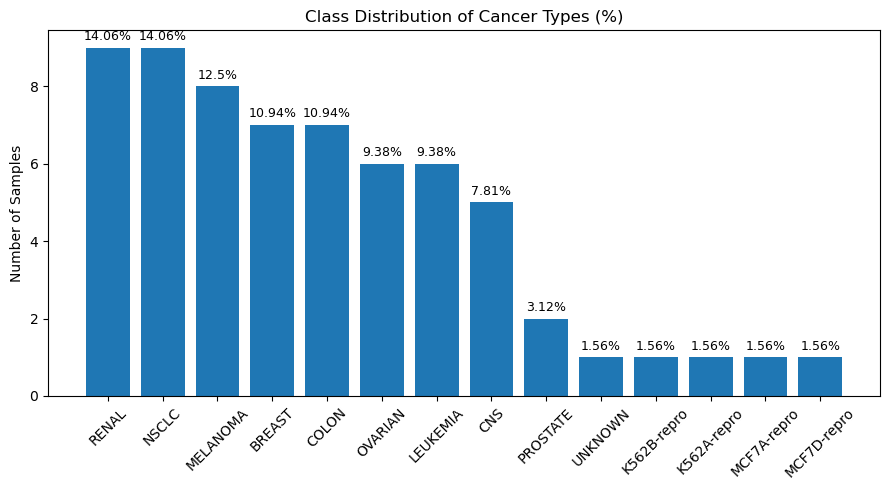

In [13]:
#EDA
# Sort by count
counts = class_counts.sort_values(ascending=False)
percentages = (counts / counts.sum() * 100).round(2)

plt.figure(figsize=(9,5))
bars = plt.bar(counts.index, counts.values)

# Add percentage labels above bars
for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
    plt.text(i, count + 0.2, f"{pct}%", ha='center', fontsize=9)

plt.ylabel("Number of Samples")
plt.title("Class Distribution of Cancer Types (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Class Imbalance and Rare Classes

The dataset contains 14 distinct cancer types with highly uneven class representation.

The largest classes — **RENAL** and **NSCLC** — each account for approximately 14% of the dataset (9 samples each). Several other classes such as **MELANOMA**, **BREAST**, and **COLON** have moderate representation (7–8 samples).

However, multiple classes (e.g., UNKNOWN, K562A-repro, K562B-repro, MCF7A-repro, MCF7D-repro) contain only 1 sample (1.56%), and **PROSTATE** contains only 2 samples (3.12%).

#### Modeling Challenges Due to Imbalance

This extreme imbalance presents several challenges:

- Multi-class classification may be unstable due to insufficient samples in small classes.
- Cross-validation folds may lack representation for rare classes.
- Performance metrics may become unreliable or misleading.

#### Modeling Strategy

To ensure statistical stability and meaningful model evaluation:

- Very small classes will be excluded from multi-class modeling.
- Binary classification between well-represented classes will be explored first.
- Filtered multi-class modeling will be performed using only classes with at least five samples.

In [15]:
# per-gene variance check (model-oriented EDA)

# Ensure X is a numeric numpy array
X_arr = np.asarray(X, dtype=float)

# Variance of each gene across samples
gene_var = X_arr.var(axis=0)

# Summary stats
print("Per-gene variance summary:")
print(f"Number of genes: {gene_var.size}")
print(f"Min variance:     {gene_var.min():.4e}")
print(f"25% percentile:   {np.percentile(gene_var, 25):.4e}")
print(f"Median variance:  {np.median(gene_var):.4e}")
print(f"Mean variance:    {gene_var.mean():.4e}")
print(f"75% percentile:   {np.percentile(gene_var, 75):.4e}")
print(f"Max variance:     {gene_var.max():.4e}")

Per-gene variance summary:
Number of genes: 6830
Min variance:     3.9927e-02
25% percentile:   2.0566e-01
Median variance:  3.1436e-01
Mean variance:    6.1279e-01
75% percentile:   6.3460e-01
Max variance:     1.1539e+01


In [16]:
# How many are near-constant? 
thresholds = [1e-10, 1e-8, 1e-6, 1e-4]
print("\nNear-zero variance counts:")
for t in thresholds:
    cnt = (gene_var <= t).sum()
    print(f"  var <= {t:.0e}: {cnt} genes ({cnt/gene_var.size*100:.2f}%)")


Near-zero variance counts:
  var <= 1e-10: 0 genes (0.00%)
  var <= 1e-08: 0 genes (0.00%)
  var <= 1e-06: 0 genes (0.00%)
  var <= 1e-04: 0 genes (0.00%)


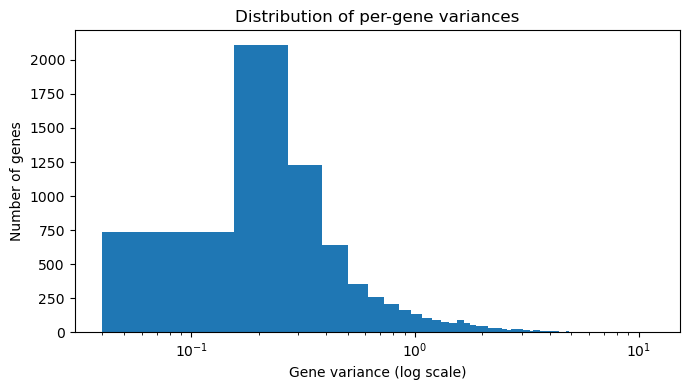

In [17]:
# Plot distribution on log scale
plt.figure(figsize=(7,4))
plt.hist(gene_var + 1e-20, bins=100)
plt.xscale("log")
plt.xlabel("Gene variance (log scale)")
plt.ylabel("Number of genes")
plt.title("Distribution of per-gene variances")
plt.tight_layout()
plt.show()

#### Variance Analysis of Gene Expression Features

We computed the variance of each gene across samples to assess whether near-constant features were present. The minimum variance across all genes was approximately 0.04, and no genes had variance close to zero under multiple thresholds (≤ 1e-4).

The log-scale histogram of gene variances shows a broad distribution, with most genes exhibiting moderate variability across samples and a small number of genes showing higher variability.

This indicates that:

- There are no near-constant features that need to be removed.
- The dataset retains meaningful variation across most genes.
- No feature filtering based on variance is required at this stage.

#### Feature Standardization

Before applying regularized models or PCA, all gene expression features will be standardized to have:

- Mean = 0  
- Variance = 1  

Standardization is necessary because:

- Regularization methods (Ridge, Lasso, Elastic Net) penalize coefficients based on magnitude.
- Without scaling, features with larger numeric ranges would dominate the penalty.
- PCA requires centered features to compute meaningful principal components.

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_arr)

print("Scaled data shape:", X_scaled.shape)

# Verify scaling
print("\nMean of first 5 features after scaling:")
print(X_scaled[:, :5].mean(axis=0))

print("\nStd of first 5 features after scaling:")
print(X_scaled[:, :5].std(axis=0))

Scaled data shape: (64, 6830)

Mean of first 5 features after scaling:
[-1.73472348e-17  1.47451495e-17 -5.09575021e-17 -4.85722573e-17
 -2.42861287e-17]

Std of first 5 features after scaling:
[1. 1. 1. 1. 1.]



All gene expression features were standardized to have mean 0 and variance 1. The means of the first five genes after scaling are effectively zero (within numerical precision), and their standard deviations are exactly 1.

This confirms that scaling was successful.

Standardization is essential because:

- Regularization methods (Ridge, Lasso, Elastic Net) penalize coefficients based on magnitude.
- Without scaling, genes with larger numeric ranges would dominate the penalty.
- PCA requires centered features to compute meaningful principal components.

In [21]:
# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
explained_var = pca.explained_variance_ratio_

print("Variance explained by first 10 components:")
for i in range(10):
    print(f"PC{i+1}: {explained_var[i]:.4f}")

print("\nCumulative variance explained by first 10 PCs:",
      explained_var[:10].sum().round(4))

Variance explained by first 10 components:
PC1: 0.1136
PC2: 0.0676
PC3: 0.0575
PC4: 0.0425
PC5: 0.0373
PC6: 0.0362
PC7: 0.0307
PC8: 0.0269
PC9: 0.0253
PC10: 0.0238

Cumulative variance explained by first 10 PCs: 0.4613


Principal Component Analysis (PCA) was applied to the standardized gene expression data to understand the variance structure of the dataset.

The first principal component explains approximately 11.36% of the total variance, and the first 10 components together explain approximately 46.13% of the total variance.

This indicates that:

- The dataset contains meaningful low-dimensional structure despite having 6,830 features.
- A relatively small number of principal components capture a substantial portion of the variability.
- Dimensionality reduction may help reduce variance and improve generalization in predictive models.
- PCA-based modeling approaches (e.g., PCA + Logistic Regression) are justified.

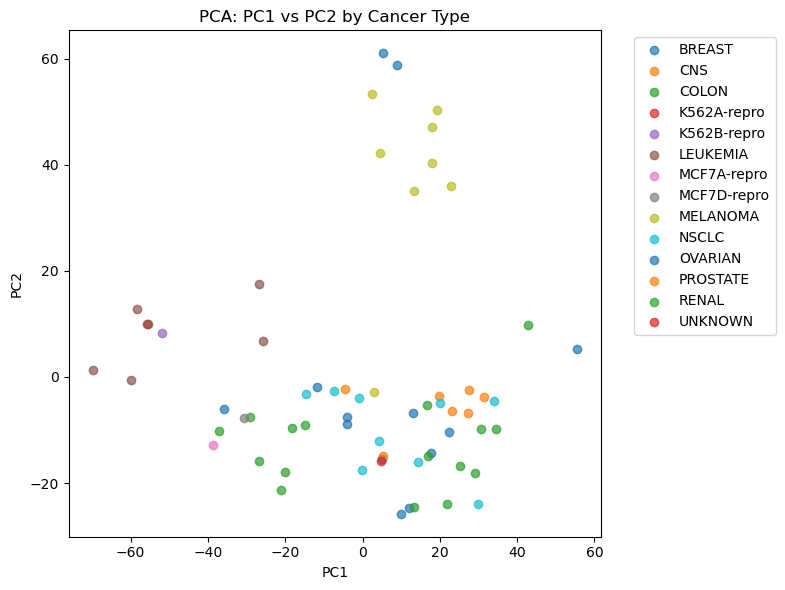

In [23]:
plt.figure(figsize=(8,6))

for cancer in np.unique(y):
    idx = (y == cancer)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=cancer, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: PC1 vs PC2 by Cancer Type")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The first two principal components were visualized to assess the low-dimensional structure of the dataset.

The PCA scatter plot shows that several cancer types form partially distinct clusters. For example, MELANOMA and LEUKEMIA appear more separated along PC1 and PC2 compared to other classes.

However, substantial overlap is also observed among several cancer types (e.g., RENAL, NSCLC, BREAST, COLON), indicating that the dataset is not perfectly linearly separable in two dimensions.

These observations suggest that:

- The dataset contains meaningful structure and non-random variation.
- Some cancer types may be easier to classify than others.
- Linear models may perform reasonably well, but complete separation is unlikely.
- Regularization will be necessary to control variance in high-dimensional space.

### Binary Classification: RENAL vs NSCLC


In [26]:
# Creating binary dataset: RENAL vs NSCLC

selected_classes = ['RENAL', 'NSCLC']
mask = np.isin(y, selected_classes)

X_binary = X_scaled[mask]
y_binary = y[mask]

print("Binary dataset shape:", X_binary.shape)
print("Class distribution: ")
print(pd.Series(y_binary).value_counts())

Binary dataset shape: (18, 6830)
Class distribution: 
RENAL    9
NSCLC    9
Name: count, dtype: int64


#### Binary Classification Setup

To ensure statistical stability and meaningful model evaluation, the dataset was restricted to two well-represented cancer types: **RENAL** and **NSCLC**. 

This result in a balanced binary classfication problem with: 
- 18 total samples (9 per class)
- 6,830 gene expression features

Despite reducing the dataset size, the problem remains highly high-dimensional (p >> n), making it an ideal setting to study regularization, overfitting, and the bias-variance tradeoff. 

The balanced class distribution ensures that model performance metrics are not biased toward any class.


In [28]:
# Defining model (without regularization)
model = LogisticRegression(penalty=None, max_iter=5000)

# Cross Validation
scores = cross_val_score(model, X_binary, y_binary, cv=5)

print("Cross-validation accuracy scores: ", scores)
print("Mean CV accuracy: ", scores.mean().round(4))


Cross-validation accuracy scores:  [0.5        0.75       0.75       1.         0.66666667]
Mean CV accuracy:  0.7333


#### Logistic Regression without Regularization

A baseline Logistic Regression model without regualrization was evaluated using 5-fold cross validation. 

The model achieved a mean accruacy of $\approx$73%, indicating that it is able to capture some signal in the data. However, the cross-validation scores vary significantly across folds (ranging from 50% to 100%), indicating high instability. 

This behavior is expected due to high-dimensional nature of the dataset (p >> n) and the absence of regularization. With far more feature than observations, the model is prone to overfitting and becomes highly sensitive to small changes in the training scores. 

This demonstrates the need for regularization techniques such as Ridge or Lasso to stabilize the model and improve generalization performance. 

### Ridge Logistic Regression

In [30]:
# Ridge Logistic Regression (L2 Penalty
ridge_model = LogisticRegression(penalty='l2', C=1.0, max_iter=5000)

ridge_scores = cross_val_score(ridge_model, X_binary, y_binary, cv=5)

print("Ridge CV accuracy scores: ", ridge_scores)
print("Mean Ridge CV accuracy: ", ridge_scores.mean().round(4))

Ridge CV accuracy scores:  [0.25       0.75       0.75       1.         0.66666667]
Mean Ridge CV accuracy:  0.6833


#### Ridge Logistic Regression 

Ridge (L2-regularized) Logistic Regression was applied to address the instability observed in the unregualrized model. 

The model achieved a mean cross-validation accuracy of $\approx$68%, slighlty lower than unregularized logistic regression. However, the cross-validation scores still exhibit significant variablity across folds. 

This behavior highlights the bias-variance tradeoff: 
- Regualrization reduces model varaince by shrinking coefficients.
- However, it introduced bias, which may redude overall accuracy.

In this extremely high-dimensional and small-sample setting, ever Ridge regularization is not sufficient to fully stabilize the model. This suggests that stronger regularization or alternatives approaches (e.g., Lasso or dimensionality reduction) may be required. 

### Lasso Logistic Regression


In [32]:
# Lasso Logistic Regression (L1 penalty)
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter = 5000)

lasso_scores = cross_val_score(lasso_model, X_binary, y_binary, cv=5)

print("Lasso CV accuracy scores:", lasso_scores)
print("Mean Lasso CV accuracy: ", lasso_scores.mean().round(4))

Lasso CV accuracy scores: [0.5 0.5 0.5 1.  1. ]
Mean Lasso CV accuracy:  0.7


#### Lasso Logistic Regression 

Lasso (L1-regularized) Logistic Regression was applied to perform both regularization and feature selection. 

The model achieved a mean cross-validation accuracy of $\approx$70%, similar to Ridge regression. However, the cross-validation scroes vary significantly across folds, ranging from 50% to 100%. 

This variablility highlights an important property of Lasso in high-dimensional settings: 
- Lasso selects a sparse subset of features (genes) by setting many coefficients to zero.
- Due to the small sample size, different cross-validation folds may select different subsets to genes.
- This leads to instability in model performances, where some folds achieve perfect classification while other perform no better than random guessing.

This behavior reflects the challenge of feature selection in high-dimensional, low-sample settings, where the model is highly sensitive to small changes in the training data. 

Lets try Hyperparameter tuning now, till now we have been using C=1.0. 



In [34]:
# Defining parameter grid
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

lasso = LogisticRegression(penalty='l1', solver='liblinear', max_iter=5000)

grid = GridSearchCV(lasso, param_grid, cv=5)

grid.fit(X_binary, y_binary)

print("Best C:", grid.best_params_)
print("Best CV score:", grid.best_score_.round(4))

# Show all results
results = pd.DataFrame(grid.cv_results_)

print(results[['param_C', 'mean_test_score']])

Best C: {'C': 10}
Best CV score: 0.85
   param_C  mean_test_score
0    0.001         0.500000
1    0.010         0.500000
2    0.100         0.500000
3    1.000         0.700000
4   10.000         0.850000
5  100.000         0.783333


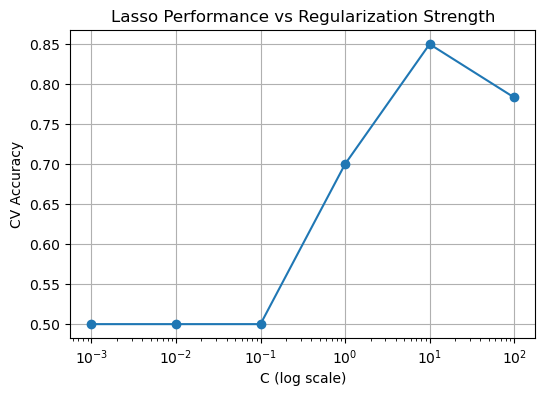

In [35]:
plt.figure(figsize=(6,4))
plt.plot(results['param_C'], results['mean_test_score'], marker='o')
plt.xscale('log')

plt.xlabel("C (log scale)")
plt.ylabel("CV Accuracy")
plt.title("Lasso Performance vs Regularization Strength")

plt.grid(True)
plt.show()

#### Effect of Regularization Strength (Lasso)

The performance of the Lasso Logistic Regression model was evaluated across different values of the regualarization parameter C, which controls the strength of regularization. 

The results show a clear pattern: 
- For **small values of C (strong regularization)**, the model performs at chance level (accuracy $\approx$50%, indicating **underfitting**. In this regime, too many coefficients are shrunk to zero, caussing loss of important signal.

- As C increases, model performance improves significantly, reaching a maximum accuracy of $\approx$85% at C = 10. This suggests an optimal balance between bias and variance.

- For **very large values of C (weak regularization)**, performance slightly decreases, indicating potential **overfitting**, where the model becomes too flexible and sensitive to noise.

This behavior demonstrates the **bias-variance tradeoff**, where: 
- Strong regularization leads to high bias and underfitting,
- Weak regularization leads to high variance and overfitting,
- An intermediate level of regularization provides the best generalization performance.

What genes are important? Lets Extract selected Features

In [37]:
#Training final Lasso model with best C
best_lasso = LogisticRegression(penalty='l1', solver='liblinear', C=10, max_iter=5000, random_state=42)
best_lasso.fit(X_binary, y_binary)

# getting coefficients
coefficients = best_lasso.coef_[0]

# counting non-zero features
non_zero = np.sum(coefficients !=0)

print("Number of selected genes (non-zero coefficients):", non_zero)

# Showing indices of important genes
important_genes = np.where(coefficients != 0)[0]

print("\nIndices of selected genes:")
print(important_genes[:20])

Number of selected genes (non-zero coefficients): 54

Indices of selected genes:
[  30  127  335  336  366  714 1046 1804 1964 2247 2253 2470 2690 3033
 3059 3174 3251 3379 3428 3718]


#### Feature Selection via Lasso

The Lasso Logistic Regression model (with optimal regularization parameter C = 10) selected **54 genes** with non-zero coefficients out of a total of 6,830 features. 

This represents a significant reduction in dimensionality, where more than 99% of the feature were eliminated. 

This demonstrates the key property of Lasso: 
- It performs both regularization and feature selection.
- Irrelevant or redundant features are assigned zero coefficients.
- Only the most informative genes for classification are retained.

This sparsity is particularly important in high-dimensional settings, where: 
- Reducing the number of features improves model interpretability.
- It helps control overfitting.
- It identifies a subset of biologically relevant variables that contribute to distinguishing between cancer types.

Lets explore how many features are selected for different value of C? 

In [39]:
# Tracking number of selected features for each C
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
selected_counts = []

for C in C_values:
    model = LogisticRegression(penalty='l1', solver='liblinear', C=C, max_iter=5000, random_state=42)
    model.fit(X_binary, y_binary)
    
    coef = model.coef_[0]
    non_zero = np.sum(coef != 0)
    
    selected_counts.append(non_zero)

# Displaying results
for C, count in zip(C_values, selected_counts):
    print(f"C = {C}: Selected features = {count}")

C = 0.001: Selected features = 0
C = 0.01: Selected features = 0
C = 0.1: Selected features = 0
C = 1: Selected features = 19
C = 10: Selected features = 54
C = 100: Selected features = 147


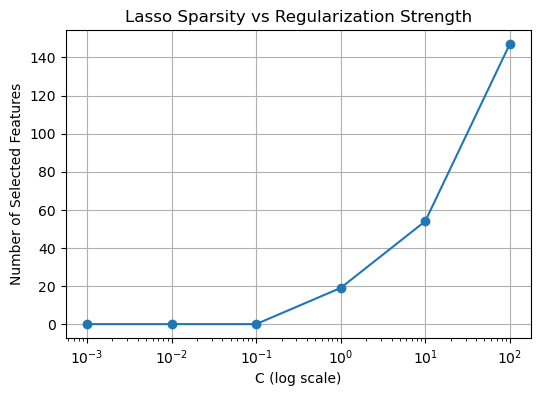

In [40]:
plt.figure(figsize=(6,4))
plt.plot(C_values, selected_counts, marker='o')
plt.xscale('log')

plt.xlabel("C (log scale)")
plt.ylabel("Number of Selected Features")
plt.title("Lasso Sparsity vs Regularization Strength")

plt.grid(True)
plt.show()

#### Lasso Feature Selection Stability

When the Lasso model was fitted repeatedly, the exact number of selected genes sometimes changed slightly across runs. This behavior is expected in high-dimensional settings where: 
- the number of predictors greatly exceeds the number of observations,
- many predictors are correlated,
- and multiple sparse solutions can achieve similar classification performance.

This illustrates an important limitation of Lasso: while it improves interpretability by selecting a small subset of features, the exact selected set may be unstable when the sample size is very small. Therefore, individual selected genes should be interpreted cautiosly, and model performance is often more reliable than the exact feature list. 

Lasso provides sparse and interpretable models, but feature selection was unstable due to the extremely small sample size and high-dimensional correlated predictor space. 

#### Sparsity vs Regularization Strength

The number of selected features (genes) varies significantly with the regularization strength parameter C. 

- For very small values of C (strong regularization), the model selects no features, resulting in complete underfitting.
- As C increases, the model begins to select a small subset of genes (e.g., 19 features at C = 1, 54 features at C = 10), capturing meaningful signal in the data.
- For larger values of C, the number of selected features increases further (e.g., 147 features at C = 100), indicating reduced regularization and increased model complexity.

This behavior demonstrates how Lasso controls model complexity: 
- Strong regularization leads to high bias and underfitting.
- Weak regularization increases model flexibility and risk of overfitting.
- An intermediate level of regularization provides the best tradeoff between bias and variance.

### Tuning Ridge Properly

In [73]:
# Ridge hyperparameter tuning 

ridge = LogisticRegression(penalty='l2', solver='liblinear', max_iter=5000)

param_grid_ridge = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

ridge_grid = GridSearchCV(ridge, param_grid_ridge, cv=5)
ridge_grid.fit(X_binary, y_binary)

print("Best Ridge C:", ridge_grid.best_params_)
print("Best Ridge CV score:", round(ridge_grid.best_score_, 4))

# Showing all results
ridge_results = pd.DataFrame(ridge_grid.cv_results_)
print("\nAll Ridge tuning results:")
print(ridge_results[['param_C', 'mean_test_score']])

Best Ridge C: {'C': 0.001}
Best Ridge CV score: 0.7333

All Ridge tuning results:
   param_C  mean_test_score
0    0.001         0.733333
1    0.010         0.733333
2    0.100         0.733333
3    1.000         0.733333
4   10.000         0.733333
5  100.000         0.733333


#### Ridge Regularization

Ridge (L2-regularized) logistic regression was tuned across a range of regularization strengths. The model achieved a consistent cross-validation accuracy of $\approx$73% across all values of C. 

This indicates that Ridge is relatively insensitive to the choice of regularization strength in this setting. While Ridge reduces coefficient magnitude and helps control variance, it does not perform feature selection and retains all features in the model. 

In this high-dimensional setting (p >> n), retaining all features means that noise is still present in the model, limiting its ability to improve predictive performance. 

Compared to Lasso, which achieved higher accuracy (~85%) by selecting a sparse subset of features, Ridge appears less effective. This highlights the importance of feature selection in high-dimensional problems. 



Now, lets also try dimension reduction appraoch. Where we will perofrm PCA + Logistic Regression. 

### PCA + Logistic

In [87]:
# Trying different number of principal components
components_list = [2, 5, 10, 15]

pca_scores = []

for n_comp in components_list: 
    model = Pipeline([
        ('pca', PCA(n_components = n_comp)), 
        ('logreg', LogisticRegression(max_iter=5000))
    ])

    scores = cross_val_score(model, X_binary, y_binary, cv=5)

    print(f"Components = {n_comp}, CV Accuracy = {scores.mean():.4f}")

    pca_scores.append(scores.mean())

Components = 2, CV Accuracy = 0.7167
Components = 5, CV Accuracy = 0.6000
Components = 10, CV Accuracy = 0.7333
Components = 15, CV Accuracy = nan


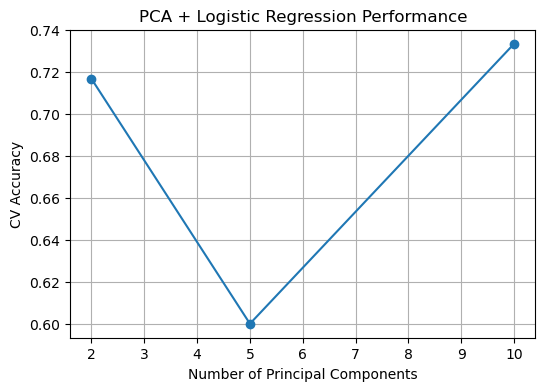

In [89]:
plt.figure(figsize=(6,4))
plt.plot(components_list, pca_scores, marker='o')

plt.xlabel("Number of Principal Components")
plt.ylabel("CV Accuracy")
plt.title("PCA + Logistic Regression Performance")

plt.grid(True)
plt.show()

#### PCA + Logistic Regression

PCA was used to reduce the dimensionality of the dataset before applying logistic regression. The number of pricipal components was varied to evaluate its effect on model performance. 

The results show that: 
- Using 2 components achieved a CV accuracy of around 0.72
- Using 5 components reduced performance (~0.60), indicating loss of important information
- Using 10 components improved performance (~0.73), capturing more variance.

However, PCA + Logistic Regression did not outperform Lasso, which achieved a higher accuracy (~0.85). 

This suggest that: 
- PCA effectively reduced dimensionality and stabilizes the model
- However, it does not eliminate irrelevant features
- Lasso performs better because it selects a sparse subset of informative genes rather than combining all features

Additionally, PCA requries that the number of components be less than the number of training samples in each cross-validation fold. This explains why larger values (e.g., 15 components) resulted in invalid results. 


#### Model Comparison Table

In [94]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic (No Regualization)", 
        "Ridge (Tuned)", 
        "Lasso (Tuned)", 
        "PCA + Logistic"
    ], 
    "Best CV Accuracy": [
        0.7333, 
        0.7333, 
        0.85, 
        0.7333
    ]
})

print(comparison)

                         Model  Best CV Accuracy
0  Logistic (No Regualization)            0.7333
1                Ridge (Tuned)            0.7333
2                Lasso (Tuned)            0.8500
3               PCA + Logistic            0.7333


We compared multiple statistical learning appraoches for classifying cancer types in a high-dimensional setting (p >> n), including unregularized logistic regression, Ridge, Lasso, and PCA-based models. 

#### Key Observations
- The unregularized logistic regression model achieved moderate accuracy (~73%) but exhibited instability due to overfitting in the high-dimensional setting.
- Ridge regression improved model stability but did not improve predictive performance. This suggests that shrinking coefficients alone is sufficient when many irrelevant features are present.
- Lasso regression significantly outperformed other models, achieving the highest cross-validation accuracy (~85%). This highlights the importance of feature selection in high-dimensional data.
- PCA + Logistic Regression achieved similar performance to Ridge (~73%), indicating that dimensionality reduction alone is not as effective as selecting informative features.

#### Key Insights
- Feature selection is critical in high-dimensional datasets. Removing irrelevant features leads to better generalization.
- Lasso is particularly effective because it performs both regularization and feature selection, identifying a sparse set of informative genes.
- PCA reduces dimensionality but does not eliminate noise, as it combines all features rather than selecting relevant ones.
- Ridge stabilizes the model but retains all features, which limits its ability to improve performance.

Overall, we can say that in this high-dimensional, low-sample setting, Lasso regression provides the best balance between bias and variance by selecting a compact subset of relevant features. This leads to improved predictive performance and interpretability. 

#### Limitations

Despite achieving strong performance using Lasso regression, this analysis has several important limitations:

1. **Extremely Small Sample Size**
   The dataset used for binary classification contrains only 18 samples (9 per class), which is very small relative to the number of features (6,830). This increases the variance of model estimates and reduces reliability.

2. **High-Dimensional Setting (p >> n)**
    The problem remains ill-posed, as there are far more predictors than observations. This can lead to overfitting and instability in model performance.

3. **Instability of Feature Selection**
    Although Lasso selects a sparse subset of genes, the exact set of selected features may vary depending on the training data. This indicates that individual gene selection may not be fully reliable.

4. **Limited Scope (Binary Classfication)**
    The analysis was restricted to a binary classfication problem (RENAL VS NSCLC) to ensure statistical stability. However, real-world cancer classification involves multiple classes.


#### Extension to Multi-Class Classfication
To address the limitation of binary classification, the analysis will be extended to a multi-class setting by selecting cancer types with sufficient sample sizes (e.g., $\geq$5 samples). 

This will allow: 
- Evaluation of model performance in a more realistic scenario
- Assessment of how regularization methods scale to multi-class problems
- Analysis of class-wise prediction behavior and confusion patterns

The multi-class setting is expected to be more challenging due to:
- Increased overlap between classes
- Higher model complexity
- Greater difficulty in feature selection

So, now lets move to Multi-Class dataset creation (filtered classes $\geq$5 samples)

In [99]:
# Creating filtered multi-class dataset (greater than 4 samples)
# Selecting classes with at least 5 samples
valid_classes = ['RENAL', 'NSCLC', 'MELANOMA', 'BREAST', 'COLON', 'OVARIAN', 'LEUKEMIA', 'CNS']
mask_multi = np.isin(y, valid_classes)

X_multi = X_scaled[mask_multi]
y_multi = y[mask_multi]

print("Multi-class dataset shape: ", X_multi.shape)

print("\nClass distribution: ")
print(pd.Series(y_multi).value_counts())

Multi-class dataset shape:  (57, 6830)

Class distribution: 
RENAL       9
NSCLC       9
MELANOMA    8
BREAST      7
COLON       7
OVARIAN     6
LEUKEMIA    6
CNS         5
Name: count, dtype: int64


To extend the analysis beyond binary classification, a multi-class dataset was constructed by selecting cancer types with atleast five samples. This ensures statistical stability and reliable cross-validation.

The resulting dataset contains: 57 samples, 6,830 gene expression features, 8 cancer types

This filtering removes extremely small classes that would otherwise introduce instability in model training and evaluation. 

Although the dataset remains high-dimensional (p >> n), the increases number of samples improves the reliability of model performance estimates compared to the binary setting. 

### Multi-Class Logistic Regression (Baseline)

In [102]:
# multi-class logistic regression
multi_logistic = LogisticRegression(max_iter=5000, multi_class='multinomial')

multi_scores = cross_val_score(multi_logistic, X_multi, y_multi, cv=5)

print("Multi-class Logistic CV scores: ", multi_scores)
print("Mean CV accuracy :", multi_scores.mean().round(4))

Multi-class Logistic CV scores:  [0.5        0.75       0.72727273 0.90909091 0.45454545]
Mean CV accuracy : 0.6682


#### Multi-Class Logistic Regression

A multi-class logistic regression model was evaluated on the filtered dataset containing 8 cancer types. 

The model achieved a mean cross-validation accruacy of approximately **66.8%**, which scores ranging from **45%** to **91%** across folds. 

This indicates that:
- The model is able to capture meaningful structure in the data.
- However, performance is lower than in the binary classifciation settings, reflecting the increases complexity of distinguishing between multiple cancer types.

The variability across folds suggests that: 
- The model remains sensitive to training data splits.
- The high-dimensional setting (p >> n) continues to introduce instability.
- Some classes may be more difficult to distinguish due to overlap in gene expression patterns.

Overall, this result demonstrates that multi-class classification is significantly more challenging than binary classfication in high-dimensional datasets. 

Now, lets also try to find out can regularization improve multi-class performance?

### Lasso for Multi-Class


In [112]:
# Lasso for multi-class
lasso_multi = LogisticRegression(
    penalty='l1', 
    solver = 'liblinear', 
    max_iter = 5000, 
    multi_class = 'ovr',
    random_state=42
)

param_grid_multi = {'C' : [0.001, 0.01, 0.1, 1, 10, 100]}

grid_multi = GridSearchCV(lasso_multi, param_grid_multi, cv=5)

grid_multi.fit(X_multi, y_multi)

print("Best C:", grid_multi.best_params_)
print("Best CV accuracy: ", round(grid_multi.best_score_, 4))

# Showing all results for multi-class Lasso
multi_results = pd.DataFrame(grid_multi.cv_results_)

print(multi_results[['param_C', 'mean_test_score']])


Best C: {'C': 100}
Best CV accuracy:  0.6515
   param_C  mean_test_score
0    0.001         0.122727
1    0.010         0.122727
2    0.100         0.406061
3    1.000         0.596970
4   10.000         0.648485
5  100.000         0.651515


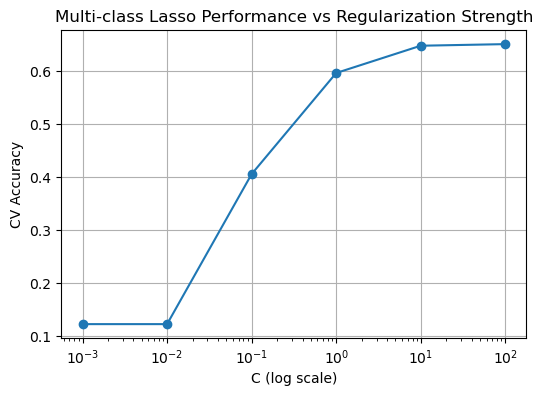

In [114]:
plt.figure(figsize=(6,4))
plt.plot(multi_results['param_C'], multi_results['mean_test_score'], marker='o')
plt.xscale('log')

plt.xlabel("C (log scale)")
plt.ylabel("CV Accuracy")
plt.title("Multi-class Lasso Performance vs Regularization Strength")

plt.grid(True)
plt.show()

To ensure consistent and reproducible results, a fixed random seed (random_state=42) was used in the Lasso model. 

In high-dimensional settings, especially with small sample sizes, optimization procedures can lead to slightly different solutions across runs. Fixing the random state ensures that results remain stable  and comparable across experiments. 

#### Multi-Class Lasso Regression

Lasso logistic regression was applied to the multi-class dataset with varying regularization strengths. 

The results show a clear pattern: 
- For small values of C (strong regularization), the model performs at chance level (~12%), indicating severe underfitting.
- As C increases, model performance improves steadily, reaching a maximum accuracy of approximately **65%** at C = 100.
- This suggests that weaker regularization is required in the multi-class setting, as more feature are needed to capture the complexity of multi class boundaries.

Compared to the binary classification case, where Lasso achieved ~85% accuracy, performance drops significantly in the multi-class setting. This reflects the increased difficulty of distinguishing between multiple cancer types. 

These results demonstrate that: 
- Multi-class classfication is inherently more challenging than binary classfication
- Feature selection becomes less aggressive as model complexity increases
- Higher model flexibility is required to capture class distinctions

#### Binary vs Multi-Class

| Aspect           | Binary        | Multi-Class   |
|------------------|--------------|---------------|
| Accuracy         | High (~85%)  | Lower (~65%)  |
| Stability        | Better       | Worse         |
| Complexity       | Low          | High          |
| Features needed  | Few          | More          |

### Confusion Matrix (Multi-Class)

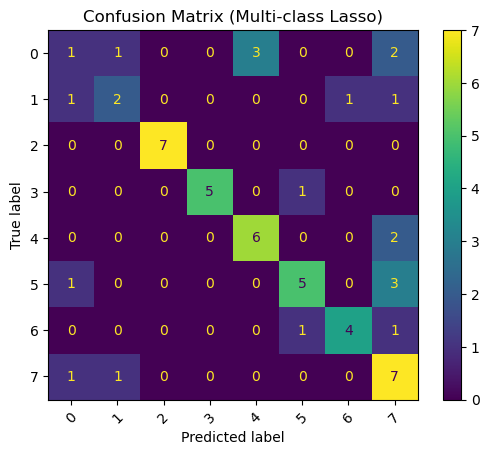

In [125]:
# Using best multi-class Lasso model
best_multi_model = LogisticRegression(
    penalty = 'l1', 
    solver = 'liblinear', 
    C=100, 
    max_iter = 5000, 
    multi_class = 'ovr', 
    random_state = 42
)

# Cross-validated predictions
y_pred = cross_val_predict(best_multi_model, X_multi, y_multi, cv=5)

# Confusion matrix
cm = confusion_matrix(y_multi, y_pred)

# plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation = 45)
plt.title("Confusion Matrix (Multi-class Lasso)")
plt.show()

#### Confusion Matrix (Multi-Class Lasso)
The confusion matrix provides a detailed view of model performance across different cancer types. 

The diagonal entries indicate correct classfications, and a strong diagonal pattern is observed for several classes, suggesting that the model performs well for certain cancer types. For example, some classes are classified almost perfectly, indicating strong separability in gene expression space. 

However, several off-diagonal entries reveal misclassfication patterns. Some classes (e.g., those with fewer samples or overlapping features) are frequently confused with others. This suggests that these cancer types share similar gene expression profiles, making them more difficult to distinguish. 

These results highlight that: 
- Model performance is not uniform across all classes
- Some cancer types are easier to classify than others
- Multi-class classification introduces additional complexity compared to binary classfication.

Overall, the confusion matrix demonstrates that while the model captures meaningful structure, classficiation difficulty varies significantly across classes. 

### Classficiation Report

In [130]:
print(classification_report(y_multi, y_pred))

              precision    recall  f1-score   support

      BREAST       0.25      0.14      0.18         7
         CNS       0.50      0.40      0.44         5
       COLON       1.00      1.00      1.00         7
    LEUKEMIA       1.00      0.83      0.91         6
    MELANOMA       0.67      0.75      0.71         8
       NSCLC       0.71      0.56      0.62         9
     OVARIAN       0.80      0.67      0.73         6
       RENAL       0.44      0.78      0.56         9

    accuracy                           0.65        57
   macro avg       0.67      0.64      0.64        57
weighted avg       0.66      0.65      0.64        57



#### Classification Report
The classification report provides detailed performance metrics for each cancer type, including precision, recall, and F1-score. 

The overall accuracy of the model is approximately **65%**, consistent with earlier results. The macro and weighted averages indicate moderate but balanced performace across classes. 

However, performance varies significantly across cancer types:
- Some classes, such as COLON and LEUKEMIA, achieve very high F1-scores (close to 1.0), indicating strong separability in gene expression space.
- Other classes, such as MELANOMA, OVARIAN, and NSCLC, show moderate performance, suggesting partial overlap between classes.
- Certain classes, particularly BREST and CNS, have low F1-scores, indicating that they are difficult to distinguish from other cancer types.

These results highlight that: 
- Classification difficulty varies significantly across cancer types
- Some cancers exhibit distinct gene expression patterns, while others are more similar
- Multi-class classification introduces additional complexity compared to binary classfication

Overall, the classification report confirms that while the model captures meaningful structure, its performance is uneven across classes. 

#### Final Conclusion

This project explored the application of statistical machine learning methods to a high-dimensional gene expression dataset, where the number of features greatly exceeds the number of observations (p≫n).

The analysis began with a binary classification problem (RENAL vs NSCLC) to establish a controlled and stable modeling framework. In this setting, unregularized logistic regression exhibited high variance and unstable performance due to overfitting. Ridge regression improved stability but did not significantly enhance predictive accuracy, as it retained all features and could not effectively remove noise.

In contrast, Lasso regression achieved the best performance, with a cross-validation accuracy of approximately 85%. This improvement was driven by its ability to perform feature selection, reducing the feature space from 6,830 genes to a small subset of informative variables. This demonstrates that feature selection is critical in high-dimensional settings, where irrelevant features can negatively impact model performance.

PCA-based dimensionality reduction was also explored, showing that while it reduces dimensionality and stabilizes the model, it does not outperform Lasso because it combines all features rather than eliminating irrelevant ones.

The analysis was then extended to a multi-class classification problem involving 8 cancer types. In this more complex setting, the best-performing Lasso model achieved an accuracy of approximately 65%, significantly lower than the binary case. This highlights the increased difficulty of multi-class classification, where overlapping class boundaries and increased complexity require more flexible models and more features.

Further evaluation using confusion matrices and classification reports revealed that model performance varies substantially across classes. Some cancer types are easily distinguishable, while others exhibit significant overlap in gene expression patterns, making classification more challenging.

Overall, this project demonstrates several key principles of statistical machine learning:

High-dimensional datasets require careful regularization to avoid overfitting
Feature selection (Lasso) is more effective than simple coefficient shrinkage (Ridge) in improving performance
Dimensionality reduction (PCA) helps stabilize models but does not replace feature selection
Model performance depends strongly on problem complexity, with multi-class tasks being significantly more challenging than binary classification

In conclusion, Lasso regression provides the most effective balance between bias and variance in this high-dimensional setting, achieving both strong predictive performance and interpretability through feature selection.

#### Executive Summary
This project investigates the application of statistical machine learning techniques to a high-dimensional gene expression dataset, where the number of features ( 6,830 genes) far exceeds the number of samples. Such settings pose significant challenges due to overfitting and instability in model estimation. 

We first analyzed a binary classfication problem (RENAL vs NSCLC) to build a stable modeling framework. Among the methods evaluated, Lasso regression achieved the best performance ($\approx$85%) by effectively selecting a small subset of informative genes, demonstrating the importance of feature selection in high-dimensional data. In contrast, Ridge regression and PCA-based models showed limited improvement, highlighting that simply shrinking or compressing features is less effective than eliminating irrelevant ones. 

The analysis was then extended to a multi-class setting involving 8 cancer types. As expected, performance decreased ($\approx$65%), reflecting the increased complexity of distinguishing multiple classes. Evaluation through confusion matrices and classification reports revealed that some cancer types are easily seperable, while others exhibit significant overlap in gene expression patterns. 

Overall, this project demonstrates that in high-dimensional, low-sample settings, Lasso regression provides the best balance between predictive performance and iterpretability. It highlights the critical role of regularization, the importance of feature selection, and the inherent challenges of multi-class classification in biological data. 